# Classification MLPs

primero cargamos el dataset. Las targets estan representadas por strings desde el 0 hasta el 9, asi que las pasamos a entero

In [1]:
from sklearn.datasets import fetch_openml

fashion_mnist=fetch_openml(name="Fashion-MNIST",as_frame=False)
targets=fashion_mnist.target.astype(int)

tomamos las primeras 60.000 imagenes para entrenamineto y las 10.000 que quedan para testear

In [3]:
X_train,y_train=fashion_mnist.data[:60_000],targets[:60_000]
X_test,y_test=fashion_mnist.data[60_000:],targets[60_000:]

usamos matplotlib para mostrar una imagen pero primero se tiene que hacerle reshape a [28,28]

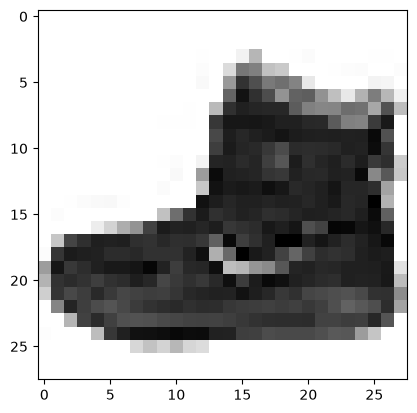

In [10]:
import matplotlib.pyplot as plt

X_sample=X_train[0].reshape(28,28) #primera imagen el el training set
plt.imshow(X_sample,cmap="binary")
plt.show()

estos son los nombres de las clases de Fashion MNIST

In [11]:
class_names=["T-shirt/Top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

In [12]:
class_names[y_train[0]]

'Ankle boot'

## Building the classification MLP

In [13]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline

mlp_clc=MLPClassifier(hidden_layer_sizes=[300,100],verbose=True,early_stopping=True,random_state=42)
pipeline=make_pipeline(MinMaxScaler(),mlp_clc)
pipeline.fit(X_train,y_train)
accuracy=pipeline.score(X_test,y_test)

Iteration 1, loss = 0.55394420
Validation score: 0.854833
Iteration 2, loss = 0.39017365
Validation score: 0.867500
Iteration 3, loss = 0.34572472
Validation score: 0.877500
Iteration 4, loss = 0.31541926
Validation score: 0.881167
Iteration 5, loss = 0.29351007
Validation score: 0.887167
Iteration 6, loss = 0.28459028
Validation score: 0.889167
Iteration 7, loss = 0.26775210
Validation score: 0.885500
Iteration 8, loss = 0.25610516
Validation score: 0.886667
Iteration 9, loss = 0.24488907
Validation score: 0.893167
Iteration 10, loss = 0.23915583
Validation score: 0.888500
Iteration 11, loss = 0.22290961
Validation score: 0.897167
Iteration 12, loss = 0.21925185
Validation score: 0.889667
Iteration 13, loss = 0.21249406
Validation score: 0.892167
Iteration 14, loss = 0.20374069
Validation score: 0.891333
Iteration 15, loss = 0.19557455
Validation score: 0.893833
Iteration 16, loss = 0.19099949
Validation score: 0.893667
Iteration 17, loss = 0.18445775
Validation score: 0.890333
Iterat

In [14]:
X_new=X_test[:15]
mlp_clc.predict(X_new)

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4])